# Notebook para o Questionário 3

Construção de um modelo de regressão para prever o preço de anúncios do Airbnb em Sydney, Austrália.

### Obtenção dos dados

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
SEED = 42

In [2]:
GITHUB_URL = (
    "https://raw.githubusercontent.com/Finance-781/FinML/master/"
    "Lecture%202%20-%20End-to-End%20ML%20Project%20/Practice/datasets/sydney_airbnb.csv"
)

df_raw = pd.read_csv(GITHUB_URL, low_memory=False)
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (27070, 84)


,id,listing_url,name,summary,space,description,neighborhood_overview,notes,transit,access,interaction,house_rules,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,...,extra_people,minimum_nights,maximum_nights,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,11156,https://www.airbnb.com/rooms/11156,An Oasis in the City,Very central to the city which can be reached ...,Potts Pt. is a vibrant and popular inner-city...,Very central to the city which can be reached ...,"It is very close to everything and everywhere,...","$150.00 key security deposit, refundable on re...",It is 7 minutes walk to the Kings Cross.train ...,Kitchen & laundry facilities. Shared bathroom.,As much as they want.,Be considerate. No showering after 2330h.,https://a0.muscache.com/im/pictures/2797669/17...,40855,https://www.airbnb.com/users/show/40855,Colleen,23/09/09,"Potts Point, New South Wales, Australia","Recently retired, I've lived & worked on 4 con...",within a day,67%,t,https://a0.muscache.com/im/users/40855/profile...,https://a0.muscache.com/im/users/40855/profile...,Potts Point,...,$0.00,2,180,4 weeks ago,t,9,39,69,339,177,5/12/09,1/07/18,92.0,9.0,9.0,10.0,10.0,10.0,9.0,f,moderate,f,f,1,1.69
1,12351,https://www.airbnb.com/rooms/12351,Sydney City & Harbour at the door,Come stay with Vinh & Stuart (Awarded as one o...,"We're pretty relaxed hosts, and we fully appre...",Come stay with Vinh & Stuart (Awarded as one o...,"Pyrmont is an inner-city village of Sydney, on...",We've a few reasons for the 6.00pm arrival tim...,Our home is centrally located and an easy walk...,We look forward to welcoming you just as we wo...,As much or as little as you like. We live here...,We look forward to welcoming you to stay you j...,https://a0.muscache.com/im/pictures/763ad5c8-c...,17061,https://www.airbnb.com/users/show/17061,Stuart,14/05/09,"Sydney, New South Wales, Australia","G'Day from Australia!\r\n\r\nHe's Vinh, and I'...",within an hour,100%,f,https://a0.muscache.com/im/users/17061/profile...,https://a0.muscache.com/im/users/17061/profile...,Pyrmont,...,$395.00,2,7,yesterday,t,13,30,45,188,468,24/07/10,27/06/18,95.0,10.0,9.0,10.0,10.0,10.0,10.0,f,strict_14_with_grace_period,t,t,2,4.83
2,14250,https://www.airbnb.com/rooms/14250,Manly Harbour House,"Beautifully renovated, spacious and quiet, our...",Our home is a thirty minute walk along the sea...,"Beautifully renovated, spacious and quiet, our...",Balgowlah Heights is one of the most prestigio...,NaN,Balgowlah - Manly bus # 131 or #132 (Bus stop...,Guests have access to whole house except locke...,NaN,Standard Terms and Conditions of Temporary Hol...,https://a0.muscache.com/im/pictures/56935671/f...,55948,https://www.airbnb.com/users/show/55948,Heidi,20/11/09,"Sydney, New South Wales, Australia",I am a Canadian who has made Australia her hom...,within a few hours,100%,f,https://a0.muscache.com/im/users/55948/profile...,https://a0.muscache.com/im/users/55948/profile...,Balgowlah,...,$40.00,5,22,4 months ago,t,0,0,0,168,1,2/01/16,2/01/16,100.0,10.0,10.0,10.0,8.0,10.0,10.0,f,strict_14_with_grace_period,f,f,2,0.03


### Limpeza dos dados

In [3]:
# Colunas selecionadas para o modelo
# Descartamos: texto livre, URLs, IDs, square_feet (>99% NaN),
# weekly_price/monthly_price (derivadas do target - vazamento de dados),
# neighbourhood_group_cleansed (100% NaN)
COLS_KEEP = [
    'price',
    'latitude', 'longitude', 'neighbourhood_cleansed',
    'property_type', 'room_type', 'accommodates',
    'bathrooms', 'bedrooms', 'beds',
    'security_deposit', 'cleaning_fee', 'extra_people', 'guests_included',
    'minimum_nights', 'maximum_nights',
    'availability_365',
    'host_since', 'host_is_superhost', 'host_identity_verified',
    'host_listings_count',
    'number_of_reviews', 'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'reviews_per_month',
    'cancellation_policy', 'instant_bookable',
    'require_guest_profile_picture', 'require_guest_phone_verification',
]

df = df_raw[COLS_KEEP].copy()
print(f"Shape após seleção: {df.shape}")

Shape após seleção: (27070, 34)


In [4]:
# Remove '$', ',' e converte para float
def parse_money(series):
    return (
        series.astype(str)
        .str.replace(r'[\$,]', '', regex=True)
        .str.strip()
        .replace('nan', np.nan)
        .astype(float)
    )

for col in ['price', 'security_deposit', 'cleaning_fee', 'extra_people']:
    df[col] = parse_money(df[col])

bool_cols = ['host_is_superhost', 'host_identity_verified',
             'instant_bookable', 'require_guest_profile_picture',
             'require_guest_phone_verification']
for col in bool_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
REFERENCE_DATE = pd.Timestamp('2019-01-01')
df['host_years'] = (REFERENCE_DATE - df['host_since']).dt.days / 365.25
df.drop(columns=['host_since'], inplace=True)

print("Tipos após conversão:")
df.dtypes

Tipos após conversão:


price                               float64
latitude                            float64
longitude                           float64
neighbourhood_cleansed                  str
property_type                           str
room_type                               str
accommodates                          int64
bathrooms                           float64
bedrooms                            float64
beds                                float64
security_deposit                    float64
cleaning_fee                        float64
extra_people                        float64
guests_included                       int64
minimum_nights                        int64
maximum_nights                        int64
availability_365                      int64
host_is_superhost                   float64
host_identity_verified              float64
host_listings_count                 float64
number_of_reviews                     int64
review_scores_rating                float64
review_scores_accuracy          

In [5]:
df = df.dropna(subset=['price'])

missing = df.isnull().mean().sort_values(ascending=False)
print("Proporção de NaN por coluna:")
print(missing[missing > 0].round(3))

Proporção de NaN por coluna:
security_deposit               0.382
cleaning_fee                   0.289
review_scores_value            0.282
review_scores_checkin          0.282
review_scores_location         0.282
review_scores_accuracy         0.281
review_scores_communication    0.280
review_scores_cleanliness      0.280
review_scores_rating           0.279
reviews_per_month              0.252
host_listings_count            0.001
host_years                     0.001
host_is_superhost              0.001
host_identity_verified         0.001
beds                           0.001
bathrooms                      0.001
bedrooms                       0.000
dtype: float64


In [6]:
p_low, p_high = df['price'].quantile([0.001, 0.99])
print(f"Preço — p0.1%: {p_low:.2f}  |  p99%: {p_high:.2f}")

df = df[(df['price'] > 0) & (df['price'] <= p_high)].copy()
df = df[df['minimum_nights'] <= 365]
df = df[df['maximum_nights'] <= 1125]

print(f"Shape após limpeza de outliers: {df.shape}")

Preço — p0.1%: 20.00  |  p99%: 1250.00
Shape após limpeza de outliers: (26769, 34)


### Estatística descritiva e análise exploratória (EDA)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,26769.0,190.596361,182.073074,1.000000,80.000000,130.000000,221.000000,1250.000000
latitude,26769.0,-33.863018,0.071432,-34.135212,-33.897708,-33.883263,-33.832408,-33.389728
longitude,26769.0,151.210169,0.079422,150.644964,151.184240,151.222701,151.264465,151.339811
accommodates,26769.0,3.333931,2.132036,1.000000,2.000000,2.000000,4.000000,16.000000
bathrooms,26747.0,1.332131,0.621343,0.000000,1.000000,1.000000,1.500000,10.000000
bedrooms,26761.0,1.589402,1.077844,0.000000,1.000000,1.000000,2.000000,46.000000
beds,26736.0,1.981860,1.487913,0.000000,1.000000,1.000000,2.000000,29.000000
security_deposit,16468.0,462.905574,598.102836,0.000000,150.000000,300.000000,500.000000,7000.000000
cleaning_fee,18998.0,90.403358,85.150496,0.000000,30.250000,69.000000,120.000000,999.000000
extra_people,26769.0,11.291681,22.995161,0.000000,0.000000,0.000000,20.000000,410.000000


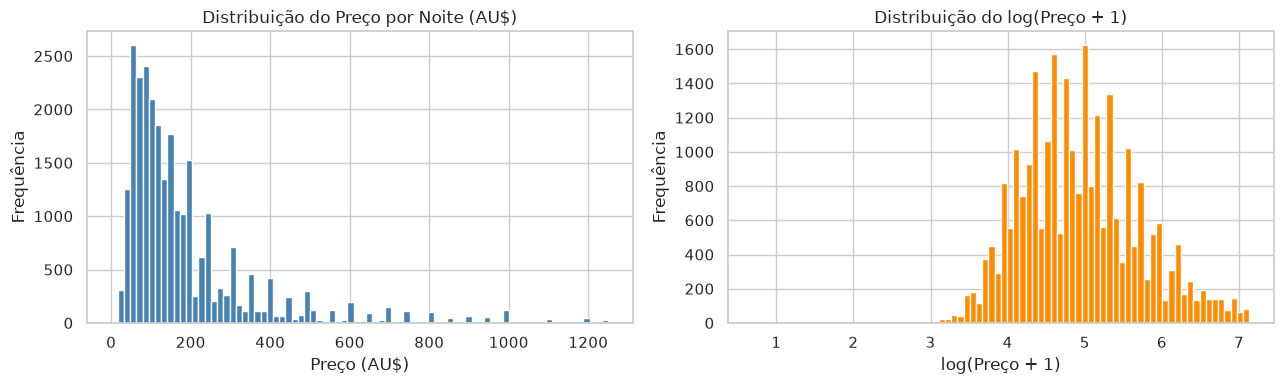

Mediana: AU$130.00  |  Média: AU$190.60


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['price'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do Preço por Noite (AU$)')
axes[0].set_xlabel('Preço (AU$)')
axes[0].set_ylabel('Frequência')

axes[1].hist(np.log1p(df['price']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Distribuição do log(Preço + 1)')
axes[1].set_xlabel('log(Preço + 1)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()
print(f"Mediana: AU${df['price'].median():.2f}  |  Média: AU${df['price'].mean():.2f}")

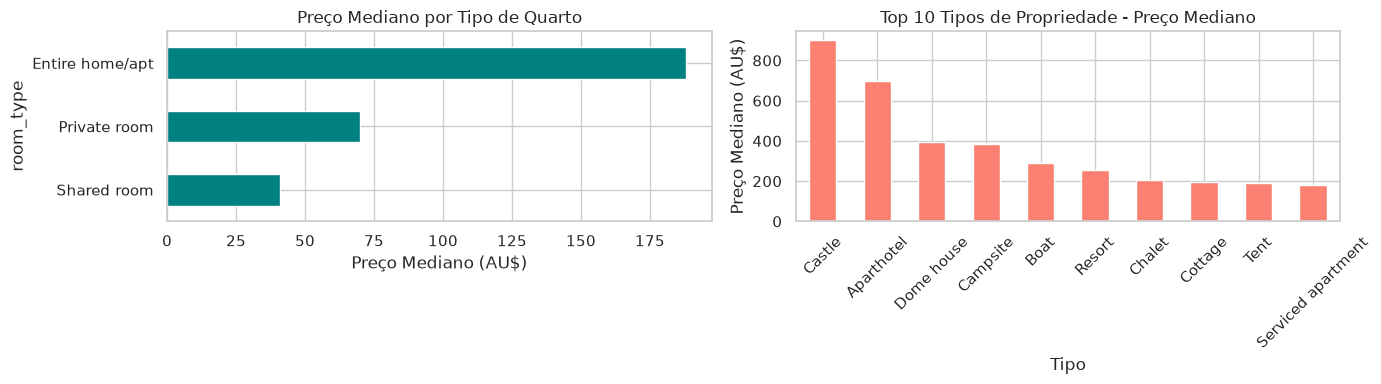

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

room_price = df.groupby('room_type')['price'].median().sort_values()
room_price.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Preço Mediano por Tipo de Quarto')
axes[0].set_xlabel('Preço Mediano (AU$)')

prop_price = (df.groupby('property_type')['price']
                .median().sort_values(ascending=False).head(10))
prop_price.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Top 10 Tipos de Propriedade - Preço Mediano')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Preço Mediano (AU$)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

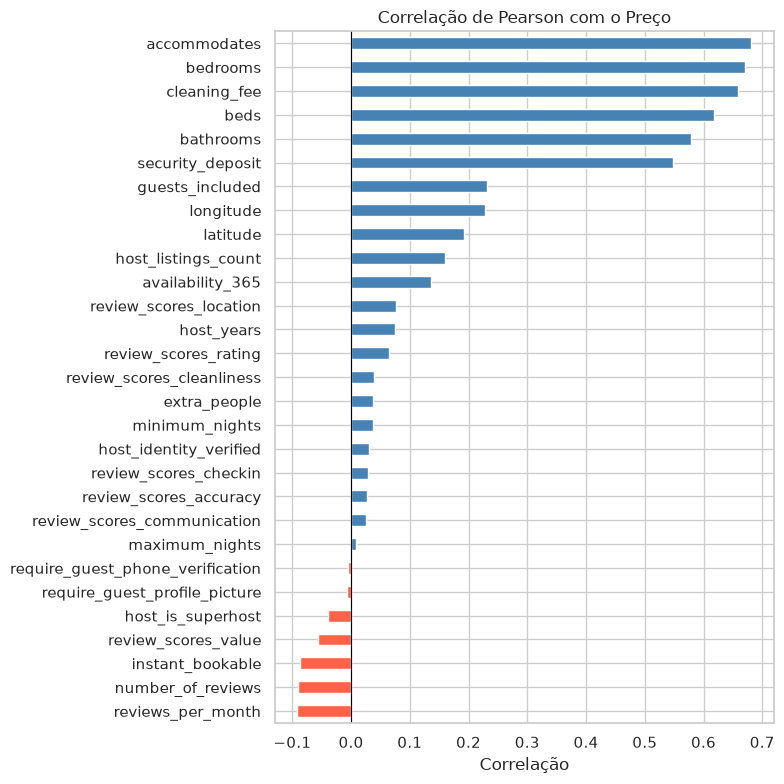

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_price = df[numeric_cols].corr()['price'].drop('price').sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = corr_with_price.map(lambda v: 'steelblue' if v >= 0 else 'tomato')
corr_with_price.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação de Pearson com o Preço')
ax.set_xlabel('Correlação')
plt.tight_layout()
plt.show()

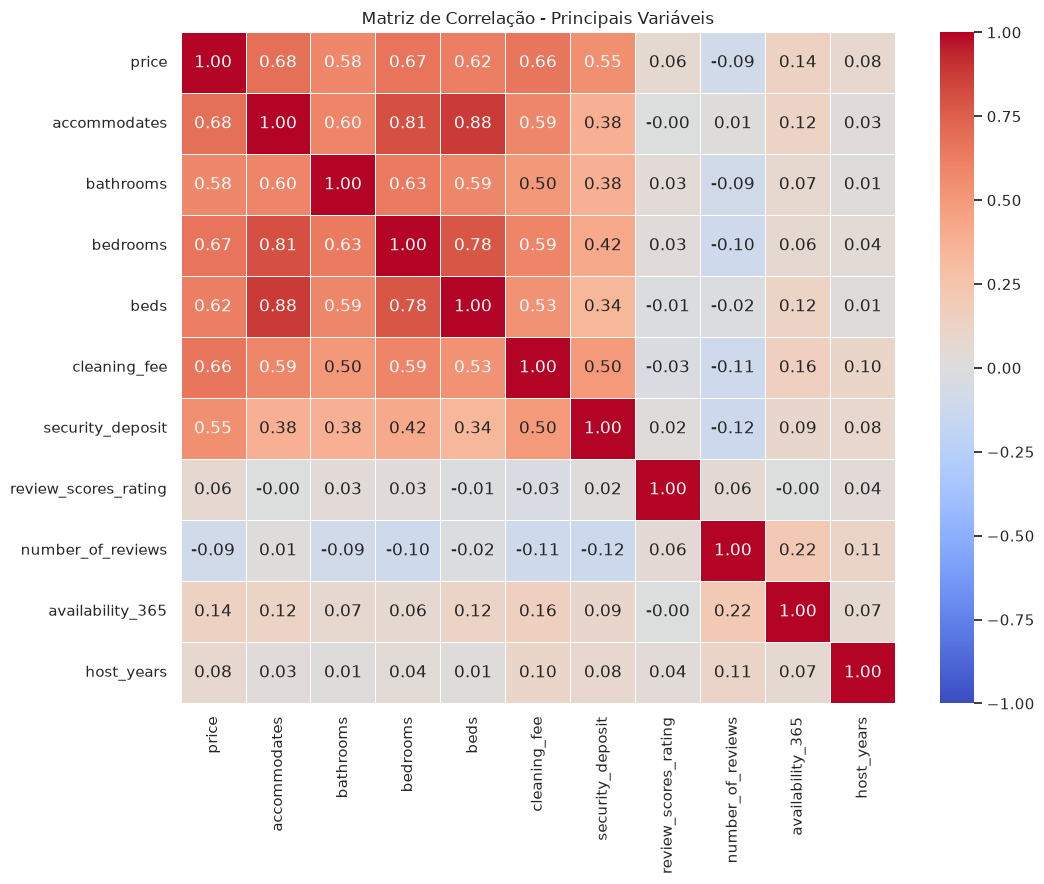

In [11]:
top_num = ['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
           'cleaning_fee', 'security_deposit', 'review_scores_rating',
           'number_of_reviews', 'availability_365', 'host_years']
top_num = [c for c in top_num if c in df.columns]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df[top_num].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlação - Principais Variáveis')
plt.tight_layout()
plt.show()

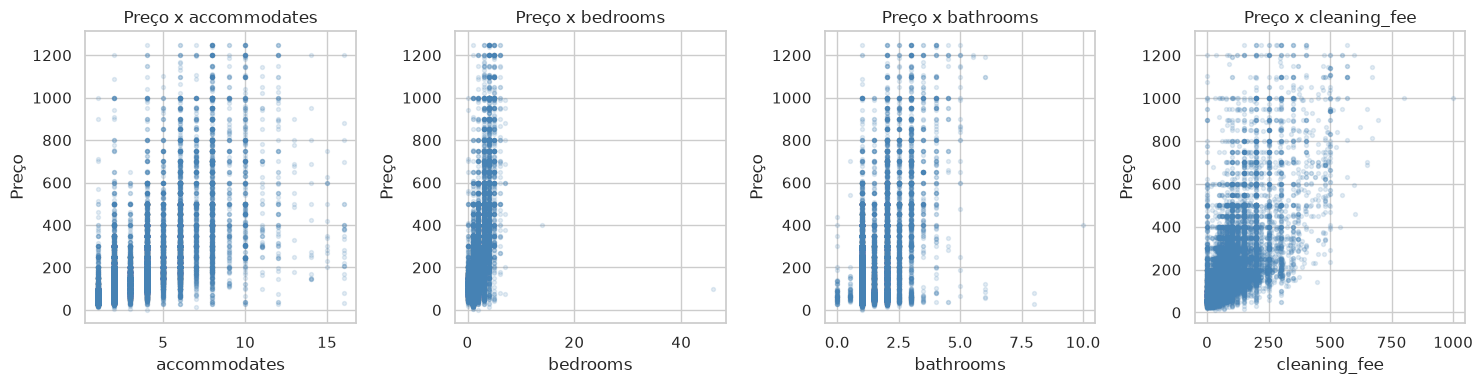

In [12]:
scatter_vars = ['accommodates', 'bedrooms', 'bathrooms', 'cleaning_fee']
scatter_vars = [c for c in scatter_vars if c in df.columns]
fig, axes = plt.subplots(1, len(scatter_vars), figsize=(15, 4))
for ax, var in zip(axes, scatter_vars):
    ax.scatter(df[var], df['price'], alpha=0.15, s=8, color='steelblue')
    ax.set_xlabel(var)
    ax.set_ylabel('Preço')
    ax.set_title(f'Preço x {var}')
plt.tight_layout()
plt.show()

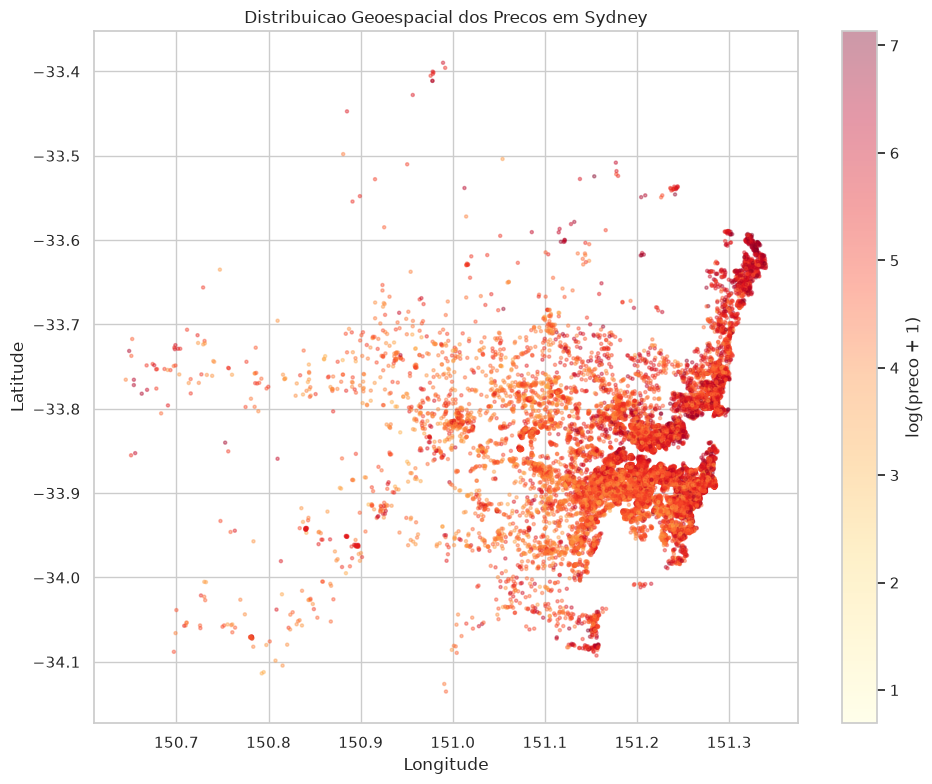

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    df['longitude'], df['latitude'],
    c=np.log1p(df['price']), cmap='YlOrRd',
    alpha=0.4, s=5
)
plt.colorbar(sc, ax=ax, label='log(preco + 1)')
ax.set_title('Distribuicao Geoespacial dos Precos em Sydney')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

### Divisão treino/teste estratificada

Estratificamos pela faixa de preço para garantir que a distribuição
seja preservada nos dois conjuntos, antes de qualquer decisão de
engenharia de atributos.

Treino: (21415, 34)  |  Teste: (5354, 34)


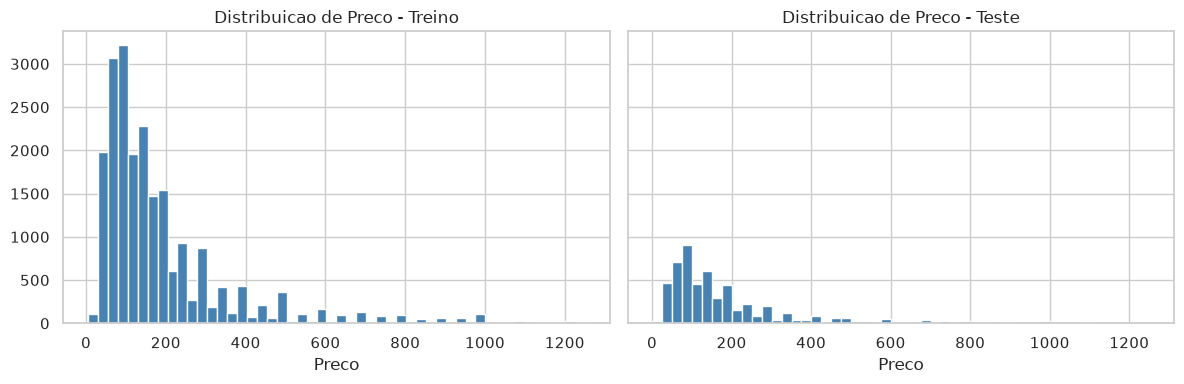

In [14]:
df['price_cat'] = pd.cut(
    df['price'],
    bins=[0, 75, 125, 200, 350, np.inf],
    labels=[1, 2, 3, 4, 5]
)

train_set, test_set = train_test_split(
    df, test_size=0.2, stratify=df['price_cat'], random_state=SEED
)

for s in [train_set, test_set, df]:
    s.drop(columns=['price_cat'], inplace=True)

print(f"Treino: {train_set.shape}  |  Teste: {test_set.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (name, subset) in zip(axes, [('Treino', train_set), ('Teste', test_set)]):
    ax.hist(subset['price'], bins=50, edgecolor='white', color='steelblue')
    ax.set_title(f'Distribuicao de Preco - {name}')
    ax.set_xlabel('Preco')
plt.tight_layout()
plt.show()

### Engenharia de atributos

Análise crítica das variáveis:

| Variável | Decisão | Justificativa |
|---|---|---|
| `id`, URLs, texto livre | **Removidas** | Sem sinal preditivo |
| `square_feet` | **Removida** | >99% de valores ausentes |
| `weekly_price`, `monthly_price` | **Removidas** | Derivadas do target (vazamento) |
| `neighbourhood_group_cleansed` | **Removida** | 100% NaN |
| `host_since` | **→ `host_years`** | Experiência em anos é mais informativa que a data bruta |
| `review_scores_*` (6 sub-scores) | **→ `review_avg`** | Altamente correlacionados entre si; reduz multicolinearidade |
| `cleaning_fee`, `security_deposit` | **Mantidas (log1p)** | Impacto direto no custo total |
| `room_density` | **Criada** | `beds / (bedrooms + 1)` — uso do espaço |
| `is_expensive_neigh` | **Criada** | Bairros com preço mediano no quartil superior |
| **Target** | **log1p(price)** | Normaliza a distribuição assimétrica do preço |

In [15]:
def feature_engineering(df_in):
    """Aplica engenharia de atributos e retorna (X, y)."""
    df_fe = df_in.copy()

    # Media das sub-notas de avaliacao
    review_sub_cols = [
        'review_scores_accuracy', 'review_scores_cleanliness',
        'review_scores_checkin', 'review_scores_communication',
        'review_scores_location', 'review_scores_value'
    ]
    existing_sub = [c for c in review_sub_cols if c in df_fe.columns]
    df_fe['review_avg'] = df_fe[existing_sub].mean(axis=1)
    df_fe.drop(columns=existing_sub, inplace=True)

    # Densidade de camas por quarto
    df_fe['room_density'] = df_fe['beds'] / (df_fe['bedrooms'].fillna(0) + 1)

    # Bairro caro (mediana > percentil 75 do conjunto)
    neigh_median = df_fe.groupby('neighbourhood_cleansed')['price'].transform('median')
    q75 = neigh_median.quantile(0.75)
    df_fe['is_expensive_neigh'] = (neigh_median >= q75).astype(int)

    # Log1p em variaveis monetarias assimetricas
    for col in ['security_deposit', 'cleaning_fee', 'extra_people']:
        df_fe[col] = np.log1p(df_fe[col].fillna(0))

    # Separacao target / features
    y = np.log1p(df_fe['price'])
    X = df_fe.drop(columns=['price'])

    return X, y


X_train, y_train = feature_engineering(train_set)
X_test,  y_test  = feature_engineering(test_set)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print("Colunas:", X_train.columns.tolist())

X_train: (21415, 30)  |  X_test: (5354, 30)
Colunas: ['latitude', 'longitude', 'neighbourhood_cleansed', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'security_deposit', 'cleaning_fee', 'extra_people', 'guests_included', 'minimum_nights', 'maximum_nights', 'availability_365', 'host_is_superhost', 'host_identity_verified', 'host_listings_count', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'cancellation_policy', 'instant_bookable', 'require_guest_profile_picture', 'require_guest_phone_verification', 'host_years', 'review_avg', 'room_density', 'is_expensive_neigh']


### Pipeline de pré-processamento

In [16]:
CAT_ORDINAL = ['cancellation_policy']
CAT_NOMINAL = ['property_type', 'room_type', 'neighbourhood_cleansed']
BOOL_COLS   = ['host_is_superhost', 'host_identity_verified',
               'instant_bookable', 'require_guest_profile_picture',
               'require_guest_phone_verification', 'is_expensive_neigh']
NUM_COLS    = [
    c for c in X_train.columns
    if c not in CAT_ORDINAL + CAT_NOMINAL + BOOL_COLS
]

CANCEL_ORDER = [['flexible', 'moderate', 'strict',
                 'strict_14_with_grace_period',
                 'super_strict_30', 'super_strict_60']]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=CANCEL_ORDER,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
    ('scaler',  StandardScaler()),
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

bool_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

preprocessor = ColumnTransformer([
    ('num',  numeric_pipeline,  NUM_COLS),
    ('ord',  ordinal_pipeline,  CAT_ORDINAL),
    ('nom',  nominal_pipeline,  CAT_NOMINAL),
    ('bool', bool_pipeline,     BOOL_COLS),
], remainder='drop')

print("Numericas :", NUM_COLS)
print("Ordinais  :", CAT_ORDINAL)
print("Nominais  :", CAT_NOMINAL)
print("Booleanas :", BOOL_COLS)
print("\nPipeline configurado com sucesso.")

Numericas : ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'security_deposit', 'cleaning_fee', 'extra_people', 'guests_included', 'minimum_nights', 'maximum_nights', 'availability_365', 'host_listings_count', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'host_years', 'review_avg', 'room_density']
Ordinais  : ['cancellation_policy']
Nominais  : ['property_type', 'room_type', 'neighbourhood_cleansed']
Booleanas : ['host_is_superhost', 'host_identity_verified', 'instant_bookable', 'require_guest_profile_picture', 'require_guest_phone_verification', 'is_expensive_neigh']

Pipeline configurado com sucesso.


### Modelos supervisionados com ajuste de hiperparâmetros

In [17]:
def rmse_price(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(np.expm1(y_true_log), np.expm1(y_pred_log)))

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred     = model.predict(X_te)
    rmse_log   = np.sqrt(mean_squared_error(y_te, y_pred))
    mae_log    = mean_absolute_error(y_te, y_pred)
    r2         = r2_score(y_te, y_pred)
    rmse_au    = rmse_price(y_te, y_pred)
    print(f"{name:<45}  RMSE(log)={rmse_log:.4f}  MAE(log)={mae_log:.4f}  "
          f"R2={r2:.4f}  RMSE(AU$)={rmse_au:.1f}")
    return {'model': model, 'RMSE_log': rmse_log, 'MAE_log': mae_log,
            'R2': r2, 'RMSE_price': rmse_au, 'y_pred': y_pred}

results = {}

In [18]:
# Regressao Linear (baseline)
lr_pipe = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
results['Linear Regression'] = evaluate(
    'Regressao Linear', lr_pipe, X_train, y_train, X_test, y_test
)

Regressao Linear                               RMSE(log)=0.4197  MAE(log)=0.3133  R2=0.6965  RMSE(AU$)=111.1


In [19]:
# Arvore de Decisao com Grid Search
dt_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', DecisionTreeRegressor(random_state=SEED))
])

dt_param_grid = {
    'model__max_depth':        [4, 6, 8, 10, None],
    'model__min_samples_leaf': [5, 10, 20, 50],
    'model__min_samples_split': [10, 20, 50],
}

dt_search = GridSearchCV(
    dt_pipe, dt_param_grid,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)
dt_search.fit(X_train, y_train)
print("Melhores hiperparametros (Arvore):", dt_search.best_params_)

results['Decision Tree'] = evaluate(
    'Arvore de Decisao (tunada)', dt_search.best_estimator_,
    X_train, y_train, X_test, y_test
)

Melhores hiperparametros (Arvore): {'model__max_depth': 10, 'model__min_samples_leaf': 50, 'model__min_samples_split': 10}
Arvore de Decisao (tunada)                     RMSE(log)=0.4246  MAE(log)=0.3161  R2=0.6895  RMSE(AU$)=110.0


In [20]:
# Floresta Aleatoria com Randomized Search
rf_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

rf_param_dist = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [8, 12, 16, None],
    'model__max_features':      ['sqrt', 'log2', 0.5],
    'model__min_samples_leaf':  [2, 5, 10],
    'model__min_samples_split': [5, 10, 20],
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist,
    n_iter=25, cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=SEED, verbose=1
)
rf_search.fit(X_train, y_train)
print("\nMelhores hiperparametros (Floresta):", rf_search.best_params_)

results['Random Forest'] = evaluate(
    'Floresta Aleatoria (tunada)', rf_search.best_estimator_,
    X_train, y_train, X_test, y_test
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Melhores hiperparametros (Floresta): {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
Floresta Aleatoria (tunada)                    RMSE(log)=0.3873  MAE(log)=0.2838  R2=0.7415  RMSE(AU$)=100.8


### Regularização (Ridge, Lasso e Elastic Net)

In [21]:
# Ridge (L2)
ridge_pipe = Pipeline([('prep', preprocessor), ('model', Ridge())])
ridge_search = GridSearchCV(
    ridge_pipe, {'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 500]},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
ridge_search.fit(X_train, y_train)
print("Ridge — melhor alpha:", ridge_search.best_params_)
results['Ridge'] = evaluate('Ridge (L2)', ridge_search.best_estimator_,
                             X_train, y_train, X_test, y_test)

# Lasso (L1)
lasso_pipe = Pipeline([('prep', preprocessor), ('model', Lasso(max_iter=5000))])
lasso_search = GridSearchCV(
    lasso_pipe, {'model__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1]},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
lasso_search.fit(X_train, y_train)
print("Lasso — melhor alpha:", lasso_search.best_params_)
results['Lasso'] = evaluate('Lasso (L1)', lasso_search.best_estimator_,
                             X_train, y_train, X_test, y_test)

# Elastic Net (L1 + L2) 
en_pipe = Pipeline([('prep', preprocessor), ('model', ElasticNet(max_iter=5000))])
en_search = GridSearchCV(
    en_pipe,
    {'model__alpha': [0.001, 0.01, 0.05, 0.1],
     'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
en_search.fit(X_train, y_train)
print("ElasticNet — melhores params:", en_search.best_params_)
results['ElasticNet'] = evaluate('Elastic Net (L1+L2)', en_search.best_estimator_,
                                  X_train, y_train, X_test, y_test)

Ridge — melhor alpha: {'model__alpha': 1}
Ridge (L2)                                     RMSE(log)=0.4197  MAE(log)=0.3132  R2=0.6965  RMSE(AU$)=111.1
Lasso — melhor alpha: {'model__alpha': 0.0001}
Lasso (L1)                                     RMSE(log)=0.4201  MAE(log)=0.3134  R2=0.6960  RMSE(AU$)=111.1
ElasticNet — melhores params: {'model__alpha': 0.001, 'model__l1_ratio': 0.1}
Elastic Net (L1+L2)                            RMSE(log)=0.4209  MAE(log)=0.3139  R2=0.6948  RMSE(AU$)=111.4


---
### Comparação final via validação cruzada

In [22]:
candidates = {
    'Linear Regression': lr_pipe,
    'Decision Tree':     dt_search.best_estimator_,
    'Random Forest':     rf_search.best_estimator_,
    'Ridge':             ridge_search.best_estimator_,
    'Lasso':             lasso_search.best_estimator_,
    'ElasticNet':        en_search.best_estimator_,
}

cv_results = {}
print(f"{'Modelo':<30} {'RMSE(log) medio':>18} {'std':>8}")
print('-' * 60)
for name, model in candidates.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    rmse_cv = -scores
    cv_results[name] = rmse_cv
    print(f"{name:<30} {rmse_cv.mean():>18.4f} {rmse_cv.std():>8.4f}")

Modelo                            RMSE(log) medio      std
------------------------------------------------------------
Linear Regression                          0.4121   0.0120
Decision Tree                              0.4146   0.0076
Random Forest                              0.3739   0.0052
Ridge                                      0.4119   0.0119
Lasso                                      0.4119   0.0116
ElasticNet                                 0.4125   0.0115


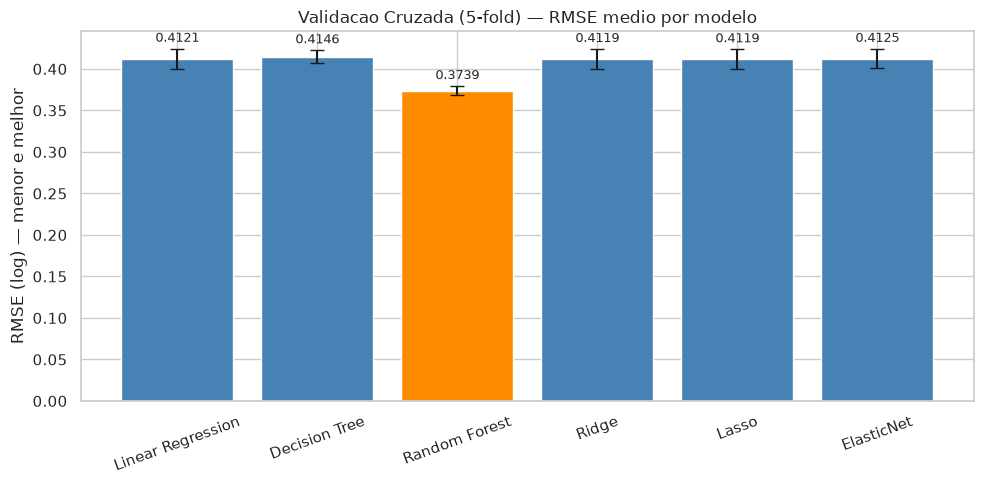


Melhor modelo na CV: Random Forest


In [23]:
names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]
best_idx = int(np.argmin(means))
colors = ['steelblue'] * len(names)
colors[best_idx] = 'darkorange'

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors, edgecolor='white')
ax.set_ylabel('RMSE (log) — menor e melhor')
ax.set_title('Validacao Cruzada (5-fold) — RMSE medio por modelo')
ax.tick_params(axis='x', rotation=20)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

best_model_name = names[best_idx]
best_model      = candidates[best_model_name]
print(f"\nMelhor modelo na CV: {best_model_name}")

### Avaliação no conjunto de teste

In [24]:
best_model.fit(X_train, y_train)
y_pred_test = best_model.predict(X_test)

rmse_log   = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_log    = mean_absolute_error(y_test, y_pred_test)
r2         = r2_score(y_test, y_pred_test)
rmse_au    = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_test)))
mae_au     = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_test))

print(f"=== {best_model_name} - Conjunto de Teste ===")
print(f"  RMSE (log)   : {rmse_log:.4f}")
print(f"  MAE  (log)   : {mae_log:.4f}")
print(f"  R-quadrado   : {r2:.4f}")
print(f"  RMSE (AU$)   : {rmse_au:.2f}")
print(f"  MAE  (AU$)   : {mae_au:.2f}")

=== Random Forest - Conjunto de Teste ===
  RMSE (log)   : 0.3873
  MAE  (log)   : 0.2838
  R-quadrado   : 0.7415
  RMSE (AU$)   : 100.80
  MAE  (AU$)   : 54.93


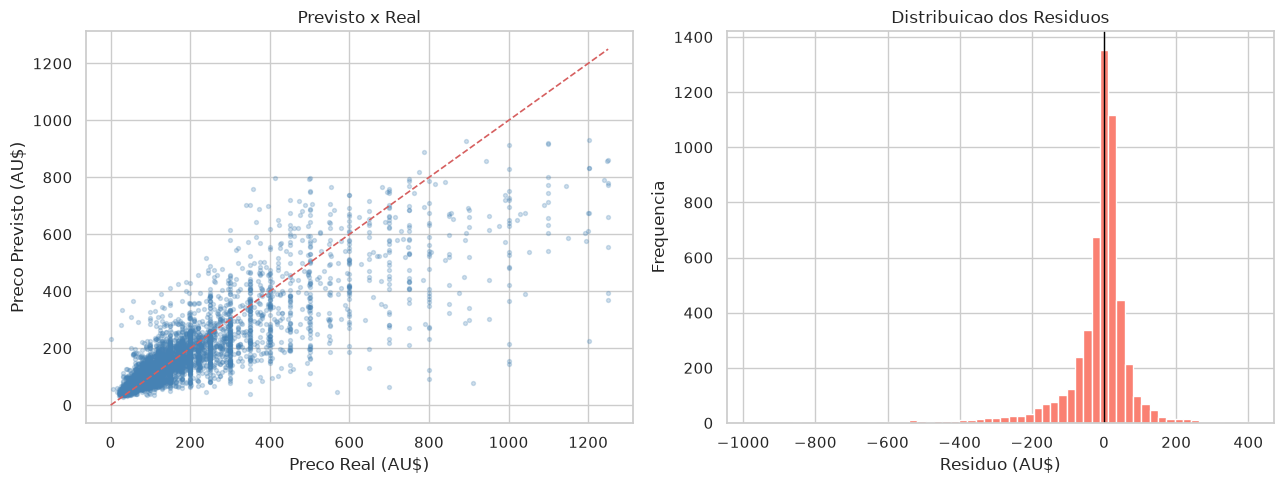

In [25]:
y_test_price = np.expm1(y_test)
y_pred_price = np.expm1(y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_price, y_pred_price, alpha=0.25, s=8, color='steelblue')
lim = max(y_test_price.max(), y_pred_price.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.2)
axes[0].set_xlabel('Preco Real (AU$)')
axes[0].set_ylabel('Preco Previsto (AU$)')
axes[0].set_title('Previsto x Real')

residuals = y_pred_price - y_test_price
axes[1].hist(residuals, bins=60, edgecolor='white', color='salmon')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Residuo (AU$)')
axes[1].set_ylabel('Frequencia')
axes[1].set_title('Distribuicao dos Residuos')

plt.tight_layout()
plt.show()

### Importância das variáveis

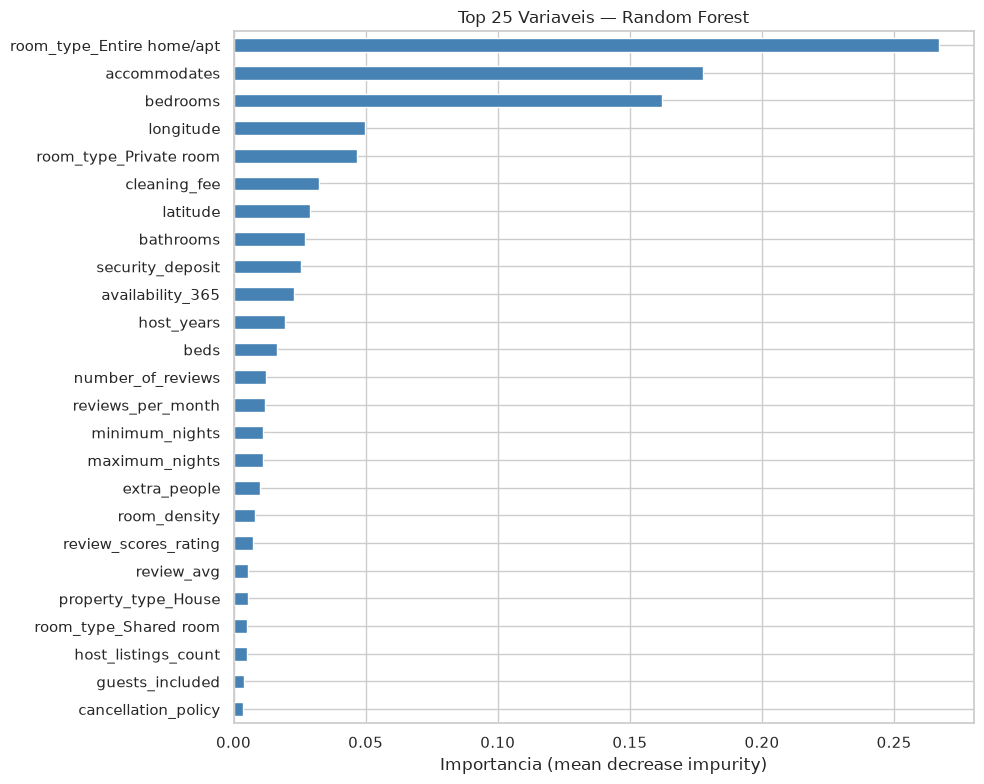


Top 10 variaveis mais importantes:
room_type_Entire home/apt    0.2669
accommodates                 0.1777
bedrooms                     0.1622
longitude                    0.0499
room_type_Private room       0.0468
cleaning_fee                 0.0323
latitude                     0.0288
bathrooms                    0.0270
security_deposit             0.0254
availability_365             0.0227
dtype: float64


In [26]:
def get_feature_names(prep, num_cols, cat_ordinal, cat_nominal, bool_cols):
    names = list(num_cols) + list(cat_ordinal)
    ohe = prep.named_transformers_['nom']['encoder']
    names += list(ohe.get_feature_names_out(cat_nominal))
    names += list(bool_cols)
    return names

fitted_prep    = best_model.named_steps['prep']
feature_names  = get_feature_names(fitted_prep, NUM_COLS, CAT_ORDINAL,
                                    CAT_NOMINAL, BOOL_COLS)
final_est      = best_model.named_steps['model']

if hasattr(final_est, 'feature_importances_'):
    imp = pd.Series(final_est.feature_importances_,
                    index=feature_names).sort_values(ascending=False)
    label = 'Importancia (mean decrease impurity)'
elif hasattr(final_est, 'coef_'):
    imp = pd.Series(np.abs(final_est.coef_),
                    index=feature_names).sort_values(ascending=False)
    label = '|Coeficiente|'

fig, ax = plt.subplots(figsize=(10, 8))
imp.head(25).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top 25 Variaveis — {best_model_name}')
ax.set_xlabel(label)
plt.tight_layout()
plt.show()

print("\nTop 10 variaveis mais importantes:")
print(imp.head(10).round(4))

### Aplicação prática: Estimação do preço justo para Bondi Beach

O anfitrião cobra atualmente AU$ 500 por noite.
Usamos o modelo final para estimar quanto ele deveria cobrar, dado o perfil do imóvel.

In [28]:
novo_imovel = pd.DataFrame([{
    "latitude":                 -33.889087,
    "longitude":                151.274506,
    "review_scores_rating":     95,
    "number_of_reviews":        53,
    "minimum_nights":           4,
    "maximum_nights":           365,
    "security_deposit":         1500,
    "cleaning_fee":             370,
    "accommodates":             10,
    "bathrooms":                3,
    "bedrooms":                 5,
    "beds":                     7,
    "property_type":            "House",
    "room_type":                "Entire home/apt",
    "availability_365":         255,
    "host_identity_verified":   1,
    "host_is_superhost":        1,
    "cancellation_policy":      "strict_14_with_grace_period",
    "guests_included":          1,
    "extra_people":             0,
    "host_listings_count":      1,
    "instant_bookable":         0,
    "require_guest_profile_picture":    0,
    "require_guest_phone_verification": 0,
    "review_scores_accuracy":      9.8,
    "review_scores_cleanliness":   9.8,
    "review_scores_checkin":       9.9,
    "review_scores_communication": 9.9,
    "review_scores_location":      9.9,
    "review_scores_value":         9.5,
    "neighbourhood_cleansed":   "Waverley",
    "reviews_per_month":        1.0,
    "price":                    500,
}])

# Calcula host_years (hospedeiro desde 2010 = ~14 anos até 2024)
host_since = pd.Timestamp("2010-08-01")
novo_imovel['host_years'] = (REFERENCE_DATE - host_since).days / 365.25

# Aplicamos a mesma engenharia de atributos
X_bondi, _ = feature_engineering(novo_imovel)

# Waverley/Bondi Beach e bairro premium -> sinalizamos manualmente
X_bondi['is_expensive_neigh'] = 1

# Predicao
log_pred   = best_model.predict(X_bondi)[0]
price_pred = np.expm1(log_pred)

CURRENT_PRICE = 500
diff_pct = (CURRENT_PRICE - price_pred) / price_pred * 100

print("=" * 55)
print(f"  Preco estimado pelo modelo  : AU$ {price_pred:>8.2f} / noite")
print(f"  Preco cobrado pelo anfitrao : AU$ {CURRENT_PRICE:>8.2f} / noite")
print(f"  Diferenca                   : {diff_pct:>+.1f}%")
print("=" * 55)

if diff_pct > 10:
    print("\nO anfitrao esta COBRANDO MAIS do que o modelo sugere.")
elif diff_pct < -10:
    print("\nO anfitrao esta COBRANDO MENOS do que o modelo sugere.")
else:
    print("\nO preco cobrado esta ALINHADO com a estimativa do modelo.")

  Preco estimado pelo modelo  : AU$   663.70 / noite
  Preco cobrado pelo anfitrao : AU$   500.00 / noite
  Diferenca                   : -24.7%

O anfitrao esta COBRANDO MENOS do que o modelo sugere.


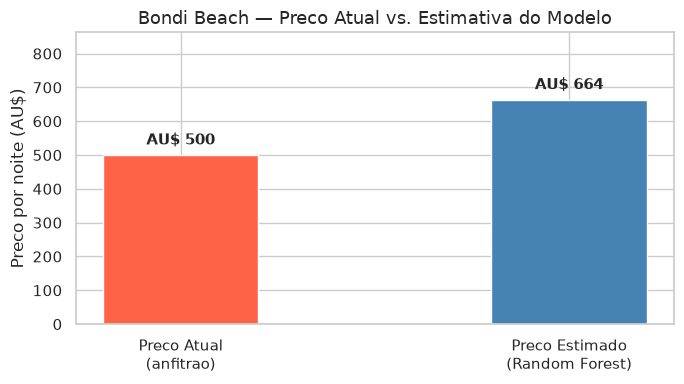

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
bar_labels = ['Preco Atual\n(anfitrao)', f'Preco Estimado\n({best_model_name})']
bar_values = [CURRENT_PRICE, price_pred]
bar_colors = ['tomato', 'steelblue']

bars = ax.bar(bar_labels, bar_values, color=bar_colors, edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='AU$ %.0f', padding=5, fontsize=11, fontweight='bold')
ax.set_title('Bondi Beach — Preco Atual vs. Estimativa do Modelo', fontsize=13)
ax.set_ylabel('Preco por noite (AU$)')
ax.set_ylim(0, max(bar_values) * 1.3)
plt.tight_layout()
plt.show()

In [30]:
# Intervalo de confianca informal usando o RMSE do melhor modelo no conjunto de teste
rmse_price_best = np.sqrt(mean_squared_error(
    np.expm1(y_test), np.expm1(best_model.predict(X_test))
))

lower = max(0, price_pred - rmse_price_best)
upper = price_pred + rmse_price_best

print(f"Estimativa pontual : AU$ {price_pred:.2f}")
print(f"Intervalo (+-RMSE) : AU$ {lower:.2f}  a  AU$ {upper:.2f}")
print(f"\nO preco atual AU$ {CURRENT_PRICE} esta "
      f"{'dentro' if lower <= CURRENT_PRICE <= upper else 'FORA'} "
      "do intervalo estimado.")

Estimativa pontual : AU$ 663.70
Intervalo (+-RMSE) : AU$ 562.90  a  AU$ 764.50

O preco atual AU$ 500 esta FORA do intervalo estimado.
